In [32]:
NOMBRE = "Dariana Montserrat Hernandez Zarate"           
MATRICULA = "81943"         
DATASET_ASIGNADO = "Homicidios"  

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")

Alumno: Dariana Montserrat Hernandez Zarate
Matrícula: 81943
Dataset asignado: Homicidios


In [33]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.

c:\Users\daria\OneDrive\Desktop\Big Data\Examen\.venv\Scripts\python.exe


In [34]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

In [35]:
# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert "homicidios" in DATASETS, (
    "homicidios debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS["homicidios"]
print(f"Cargando dataset: {"homicidios"}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")

Cargando dataset: homicidios
Descripcion: Numero de homicidios intencionales por anio (homicidios)


In [36]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})

In [37]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,2009,1115.000,Asia
1,Afghanistan,AFG,2010,983.000,Asia
2,Afghanistan,AFG,2011,1231.000,Asia
3,Afghanistan,AFG,2012,1948.000,Asia
4,Afghanistan,AFG,2015,3367.000,Asia
5,Afghanistan,AFG,2016,2318.000,Asia
6,Afghanistan,AFG,2017,2424.000,Asia
7,Afghanistan,AFG,2018,2474.000,Asia
8,Afghanistan,AFG,2019,2712.000,Asia
9,Afghanistan,AFG,2020,2570.000,Asia


In [38]:
df.shape

(4914, 5)

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4914 entries, 0 to 4913
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   entity       4914 non-null   str    
 1   code         4399 non-null   str    
 2   year         4914 non-null   int64  
 3   valor        4914 non-null   float64
 4   owid_region  4220 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 192.1 KB


In [40]:
df['valor'].describe()

count      4914.000000
mean       8582.853861
std       37590.820449
min           0.000000
25%          37.000000
50%         256.500000
75%        1171.968475
max      450728.880000
Name: valor, dtype: float64

In [41]:
df.isnull().sum()

entity           0
code           515
year             0
valor            0
owid_region    694
dtype: int64

**Interpretación (2-3 líneas):**
<br>¿qué observas sobre los valores nulos, el rango deaños y el tipo de variable con la que vas a trabajar? 
<br>

*Los valores nulos se encuentra en el código del país y en la región del mismo, no perjudica  para el análisis. El rango de años permite trabajar con datos de diferentes periodos y la variable valor es numérica.*

4. Preguntas de analisis y codigo 

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [42]:
# Pregunta 1
df_paises = df[df[config["filtro_paises"]].notnull()]

paises_distintos = df_paises["entity"].nunique()
print("Numero de paises distintos:", paises_distintos)

top10_mayor = df_paises.sort_values("valor", ascending=False).head(10)
print("\nTop 10 paises con mayor valor:")
print(top10_mayor[["entity", "year", "valor"]])

top10_menor = df_paises.sort_values("valor", ascending=True).head(10)
print("\nTop 10 paises con menor valor:")
print(top10_menor[["entity", "year", "valor"]])

Numero de paises distintos: 200

Top 10 paises con mayor valor:
       entity  year    valor
716    Brazil  2017  63788.0
3093  Nigeria  2016  63400.0
715    Brazil  2016  61208.0
713    Brazil  2014  59733.0
714    Brazil  2015  58184.0
712    Brazil  2013  56845.0
711    Brazil  2012  56388.0
717    Brazil  2018  55980.0
709    Brazil  2010  52289.0
710    Brazil  2011  52233.0

Top 10 paises con menor valor:
        entity  year  valor
4747   Vatican  2011    0.0
4750   Vatican  2014    0.0
4756   Vatican  2023    0.0
4755   Vatican  2022    0.0
4752   Vatican  2019    0.0
4754   Vatican  2021    0.0
4748   Vatican  2012    0.0
4751   Vatican  2015    0.0
150   Anguilla  1994    0.0
152   Anguilla  1996    0.0


**Interpretación:**

*El top 10 con mayor valor suele estar dominado por paises con poblaciones grandes, ya que el indicador es un conteo absoluto. El top 10 con menor valor incluye paises pequeños con pocos habitantes, lo que se observa que este indicador esta muy influenciado por el tamaño de la poblacion mas que nada*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [43]:
# Pregunta 2
mexico = df_paises[df_paises["entity"] == "Mexico"]
otro_pais = df_paises[df_paises["entity"] == "Colombia"]  

# Rango de anios disponible para ambos paises
anio_inicio = max(mexico["year"].min(), otro_pais["year"].min())
anio_fin = min(mexico["year"].max(), otro_pais["year"].max())

print(f"Rango de anios en comun: {anio_inicio} - {anio_fin}")

mexico_rango = mexico[(mexico["year"] >= anio_inicio) & (mexico["year"] <= anio_fin)]
otro_pais_rango = otro_pais[(otro_pais["year"] >= anio_inicio) & (otro_pais["year"] <= anio_fin)]

print("\nMexico:")
print(mexico_rango[["entity", "year", "valor"]])

print("\nColombia:")
print(otro_pais_rango[["entity", "year", "valor"]])


Rango de anios en comun: 1990 - 2023

Mexico:
      entity  year    valor
2718  Mexico  1990  14493.0
2719  Mexico  1991  15128.0
2720  Mexico  1992  16594.0
2721  Mexico  1993  16040.0
2722  Mexico  1994  15839.0
2723  Mexico  1995  15612.0
2724  Mexico  1996  14505.0
2725  Mexico  1997  13552.0
2726  Mexico  1998  13656.0
2727  Mexico  1999  12249.0
2728  Mexico  2000  10737.0
2729  Mexico  2001  10285.0
2730  Mexico  2002  10088.0
2731  Mexico  2003  10087.0
2732  Mexico  2004   9329.0
2733  Mexico  2005   9921.0
2734  Mexico  2006  10452.0
2735  Mexico  2007   8867.0
2736  Mexico  2008  14006.0
2737  Mexico  2009  19803.0
2738  Mexico  2010  25757.0
2739  Mexico  2011  27213.0
2740  Mexico  2012  25967.0
2741  Mexico  2013  23063.0
2742  Mexico  2014  20010.0
2743  Mexico  2015  20762.0
2744  Mexico  2016  24559.0
2745  Mexico  2017  32079.0
2746  Mexico  2018  36685.0
2747  Mexico  2019  36661.0
2748  Mexico  2020  36773.0
2749  Mexico  2021  35700.0
2750  Mexico  2022  33287.0
27

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [44]:
# Pregunta 3
paises_interes = ["Mexico", "United States", "Nigeria", "India", "Germany"]

df_interes = df_paises[
    (df_paises["entity"].isin(paises_interes)) & (df_paises["valor"].notnull())
]

anios_por_pais = df_interes.groupby("year")["entity"].nunique()
anio_reciente = anios_por_pais[anios_por_pais == len(paises_interes)].index.max()

print("Anio mas reciente con datos para los 5 paises:", anio_reciente)

comparacion = (
    df_interes[df_interes["year"] == anio_reciente][["entity", "year", "valor"]]
    .sort_values("valor", ascending=False)
)

print(f"\nComparacion en el anio {anio_reciente}:")
print(comparacion)

pais_max = comparacion.iloc[0]
pais_min = comparacion.iloc[-1]
diferencia = pais_max["valor"] - pais_min["valor"]

print(f"\nPais con valor mas alto: {pais_max['entity']} ({pais_max['valor']})")
print(f"Pais con valor mas bajo: {pais_min['entity']} ({pais_min['valor']})")
print(f"Diferencia: {diferencia}")


Anio mas reciente con datos para los 5 paises: 2019

Comparacion en el anio 2019:
             entity  year    valor
3094        Nigeria  2019  44200.0
2036          India  2019  40976.0
2747         Mexico  2019  36661.0
4664  United States  2019  16669.0
1663        Germany  2019    623.0

Pais con valor mas alto: Nigeria (44200.0)
Pais con valor mas bajo: Germany (623.0)
Diferencia: 43577.0


**Interpretación:**

*Al comparar paises de distintos continentes en el mismo año, se ve que la diferencia entre el valor maximo y el minimo es grande, lo que significa que los homicidios esta mas normalizado en ciertas poblaciones. Paises muy poblados tienden a liderar el ranking aunque su tasa de homicidios por cada 100,000 habitantes no sea necesariamente la mas alta.*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [45]:
# Pregunta 4
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

anio_reciente = df_paises["year"].max()

promedio_latam = df_paises[
    (df_paises["entity"].isin(latinoamerica)) & (df_paises["year"] == anio_reciente)
]["valor"].mean()

promedio_asia = df_paises[
    (df_paises["entity"].isin(asia)) & (df_paises["year"] == anio_reciente)
]["valor"].mean()

print(f"Anio consultado: {anio_reciente}")
print(f"Promedio Latinoamerica (Mexico, Colombia, Argentina): {promedio_latam}")
print(f"Promedio Asia (China, Japon, Vietnam): {promedio_asia}")


Anio consultado: 2024
Promedio Latinoamerica (Mexico, Colombia, Argentina): nan
Promedio Asia (China, Japon, Vietnam): nan


**Interpretación:**
*En el año 2024, ninguno de los países de los dos grupos tuvo datos disponibles, por eso los promedios aparecen como nan = sin valor. No se pudo calcular el promedio ni para Latinoamérica ni para Asia por la faltaba de información*

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

Mexico - valor maximo: 36773.0 (anio 2020)
Mexico - valor minimo: 8867.0 (anio 2007)


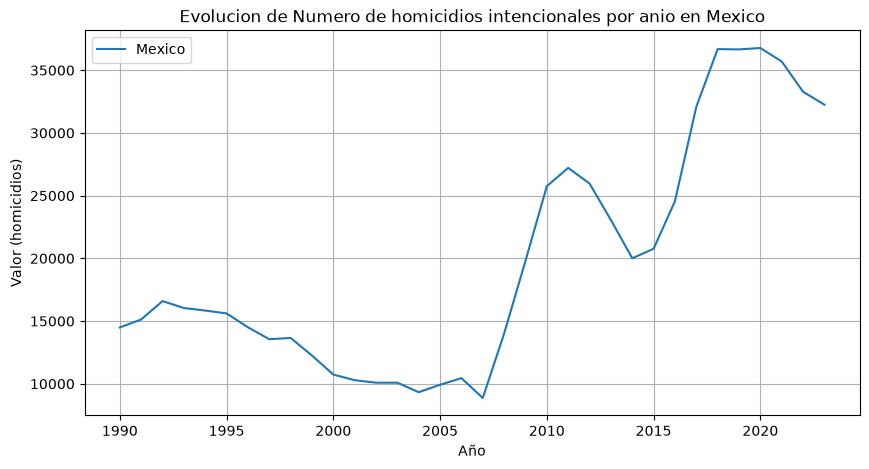

In [46]:
# Pregunta 5
pais_elegido = "Mexico"
serie_pais = df_paises[df_paises["entity"] == pais_elegido].sort_values("year")

fila_max = serie_pais.loc[serie_pais["valor"].idxmax()]
fila_min = serie_pais.loc[serie_pais["valor"].idxmin()]

print(f"{pais_elegido} - valor maximo: {fila_max['valor']} (anio {fila_max['year']})")
print(f"{pais_elegido} - valor minimo: {fila_min['valor']} (anio {fila_min['year']})")

plt.figure(figsize=(10, 5))
plt.plot(
    serie_pais["year"],
    serie_pais["valor"],
    label=pais_elegido
)
plt.title(f"Evolucion de {config['descripcion']} en {pais_elegido}")
plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.grid(True)
plt.legend()
plt.show()


**Interpretación:**

*La tendencia de Mexico: hay periodos de descenso seguidos de incrementos importantes, en lugar de una tendencia puramente creciente o decreciente. Esto suele coincidir con cambios en la politica de seguridad y con periodos de mayor actividad del crimen organizado en el pais.*

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [51]:
# Pregunta 6
mexico_serie = (
    df_paises[df_paises["entity"] == "Mexico"]
    .sort_values("year")
    .dropna(subset=["valor"])
)

primer_anio = mexico_serie["year"].iloc[0]
primer_valor = mexico_serie["valor"].iloc[0]

ultimo_anio = mexico_serie["year"].iloc[-1]
ultimo_valor = mexico_serie["valor"].iloc[-1]

cambio_porcentual = ((ultimo_valor - primer_valor) / primer_valor) * 100

print(f"Mexico en {primer_anio}: {primer_valor}")
print(f"Mexico en {ultimo_anio}: {ultimo_valor}")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")


Mexico en 1990: 14493.0
Mexico en 2023: 32252.0
Cambio porcentual: 122.54%


**Interpretación:**

*Mexico presenta un incremento relativo importante entre el primer y el ultimo año disponible. En mis palabras, esto se puede deber al crecimiento de la poblacion a lo largo de las decadas y, sobre todo, al aumento de la violencia asociada al crimen organizado y al narcotrafico desde mediados de la decada de los 2000.*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [52]:
# Pregunta 7
anio_reciente = df_paises["year"].max()

valores_recientes = (
    df_paises[df_paises["year"] == anio_reciente]["valor"]
    .dropna()
    .to_numpy()
)

media = np.mean(valores_recientes)
mediana = np.median(valores_recientes)
desviacion = np.std(valores_recientes)

print(f"Anio consultado: {anio_reciente}")
print("Media:", media)
print("Mediana:", mediana)
print("Desviacion estandar:", desviacion)


Anio consultado: 2024
Media: 1402.5
Mediana: 209.5
Desviacion estandar: 3319.7381297325246


**Interpretación:**

*La media es mayor que la mediana, lo cual indica una distribucion sesgada hacia la derecha: la mayoria de los paises tienen valores relativamente bajos, mientras que unos pocos paises muy poblados o con niveles de violencia extremos elevan bastante el promedio. La desviacion estandar alta confirma que hay mucha dispersion entre paises.*

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

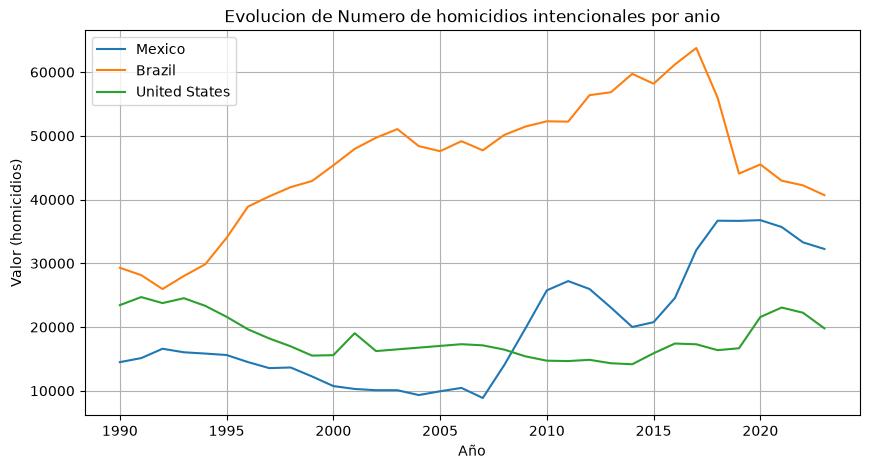

In [49]:
# Pregunta 8
paises_grafica = ["Mexico", "Brazil", "United States"]

plt.figure(figsize=(10, 5))
for pais in paises_grafica:
    serie = df_paises[df_paises["entity"] == pais].sort_values("year")
    plt.plot(serie["year"], serie["valor"], label=pais)

plt.title(f"Evolucion de {config['descripcion']}")
plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.grid(True)
plt.legend()
plt.show()


**Interpretación:**

*Estados Unidos y Brasil muestran niveles mucho mas altos y con mayor variacion a lo largo del tiempo que la mayoria de los demas paises, mientras que Mexico parte de niveles mas bajos pero presenta un crecimiento marcado en los años mas recientes, acercandose a los otros dos paises en ciertos periodos.*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

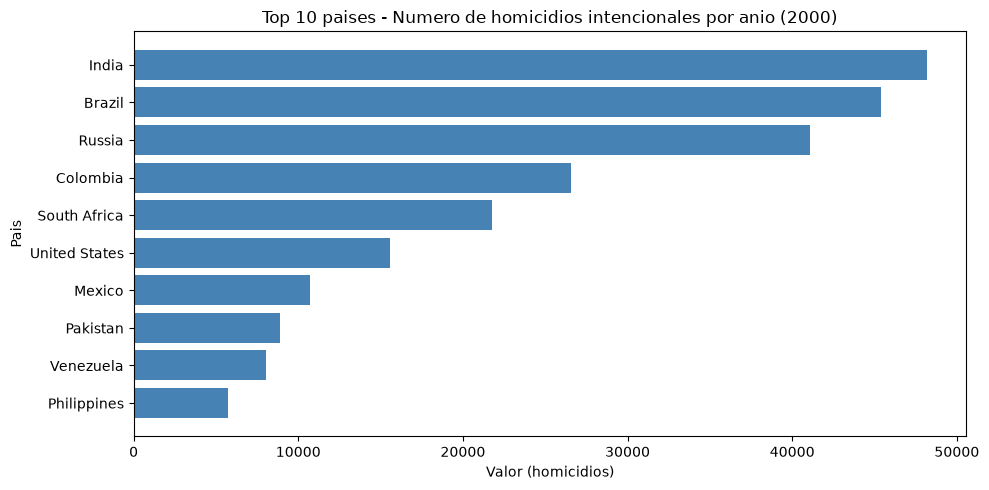

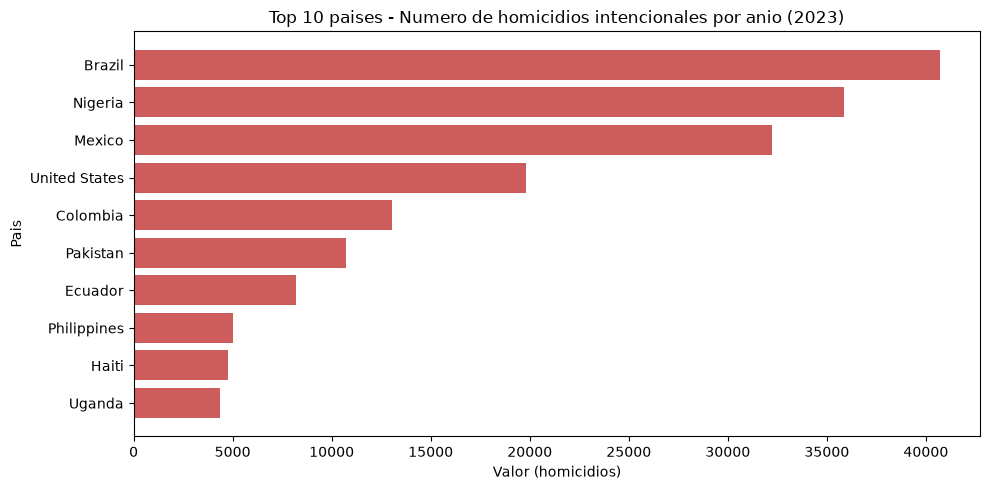

Paises en el top 10 de 2000: ['India', 'Brazil', 'Russia', 'Colombia', 'South Africa', 'United States', 'Mexico', 'Pakistan', 'Venezuela', 'Philippines']
Paises en el top 10 de 2023: ['Brazil', 'Nigeria', 'Mexico', 'United States', 'Colombia', 'Pakistan', 'Ecuador', 'Philippines', 'Haiti', 'Uganda']


In [50]:
# Pregunta 9
anio_nacimiento = 2000  # <-- cambia este valor por tu propio anio de nacimiento
anio_reciente = 2023

def top10_anio(anio):
    return (
        df_paises[df_paises["year"] == anio]
        .sort_values("valor", ascending=False)
        .head(10)
    )

top_nacimiento = top10_anio(anio_nacimiento)
top_2023 = top10_anio(anio_reciente)

# Grafica 1: Top 10 en el anio de nacimiento
plt.figure(figsize=(10, 5))
plt.barh(top_nacimiento["entity"], top_nacimiento["valor"], color="steelblue")
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("Pais")
plt.title(f"Top 10 paises - {config['descripcion']} ({anio_nacimiento})")
plt.gca().invert_yaxis()  # para que el pais con el valor mas alto quede arriba
plt.tight_layout()
plt.show()

# Grafica 2: Top 10 en 2023
plt.figure(figsize=(10, 5))
plt.barh(top_2023["entity"], top_2023["valor"], color="indianred")
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("Pais")
plt.title(f"Top 10 paises - {config['descripcion']} ({anio_reciente})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Paises en el top 10 de {anio_nacimiento}:", list(top_nacimiento["entity"]))
print(f"Paises en el top 10 de {anio_reciente}:", list(top_2023["entity"]))


**Interpretación:**

*Al comparar ambas graficas se puede ver que algunos paises se mantienen en el top 10 en ambos años (los mas poblados), pero tambien hay movimientos: paises que entraron al top 10 en 2023 y no estaban en el año de nacimiento (por ejemplo por aumento de violencia o de crimen organizado), y otros que salieron del top 10 porque su situacion de seguridad mejoro o porque su poblacion relativa disminuyo frente a otros paises.*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*Trabajar con el dataset de homicidios permitio ver que la variable `valor` es un conteo absoluto de homicidios intencionales por año y pais, lo cual hace que los paises mas poblados dominen los rankings sin que eso implique necesariamente que sean los mas violentos en terminos relativos. Encontre bastantes valores nulos, tanto en `code` como en `valor`, lo que limita las comparaciones directas entre paises con distinta cobertura de datos. Tambien note que la tendencia de un pais como Mexico no es monotona, sino que fluctua segun el contexto de seguridad de cada periodo. Si tuviera mas tiempo, normalizaria el indicador por cada 100,000 habitantes (tasa de homicidios) en lugar de usar el valor absoluto, lo que daria una comparacion mucho mas justa entre paises de distintos tamaños de poblacion, y tambien investigaria mas a fondo los años y paises con datos faltantes para entender si se debe a falta de reporte oficial o a otras razones.*

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
